DT TRAIN ACCURACY: 0.9592696629213483
DT TEST ACCURACY: 0.6312849162011173
DT TRAIN ACCURACY: 0.7331460674157303
DT TEST ACCURACY: 0.7039106145251397
REPORT               precision    recall  f1-score   support

           0       0.71      0.93      0.81       105
           1       0.83      0.46      0.59        74

    accuracy                           0.74       179
   macro avg       0.77      0.70      0.70       179
weighted avg       0.76      0.74      0.72       179

MODEL              TRAIN     TEST
--------------------------------
DT-NO-LIMIT       0.959   0.631
DT-LIMIT          0.733   0.704
RF                0.743   0.737


<Axes: >

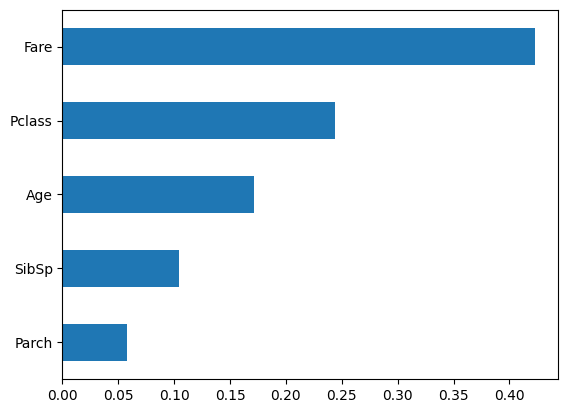

In [5]:
# Use Titanic data — same cleaning
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt 
df=pd.read_csv('train.csv')
df['Age']=df['Age'].fillna(df['Age'].median())
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df=df.drop('Cabin',axis=1)
X=df[['Age','Fare','SibSp','Pclass','Parch']]
Y=df['Survived']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

# 1. Train Decision Tree with no depth limit
#    Print train AND test accuracy
#    What do you observe? (overfitting?)
model=DecisionTreeClassifier(random_state=42)
model.fit(X_train,Y_train)
print('DT TRAIN ACCURACY:',accuracy_score(Y_train,model.predict(X_train)))
print('DT TEST ACCURACY:',accuracy_score(Y_test,model.predict(X_test)))

# 2. Train Decision Tree with max_depth=3
#    Print train AND test accuracy
#    Compare with no limit version
model=DecisionTreeClassifier(random_state=42,max_depth=3)
model.fit(X_train,Y_train)
print('DT TRAIN ACCURACY:',accuracy_score(Y_train,model.predict(X_train)))
print('DT TEST ACCURACY:',accuracy_score(Y_test,model.predict(X_test)))

# 3. Train Random Forest with:
#    n_estimators=50, max_depth=4
#    Print classification report
#    Which class has better recall?
rf=RandomForestClassifier(n_estimators=50,max_depth=4,random_state=42)
rf.fit(X_train,Y_train)
print('REPORT',classification_report(Y_test,rf.predict(X_test)))
#DIED AS BETTER RECALL IT PREDICTS DEAD MORE I AM SAYING THIS BY SEEING PRECISION AND RECALL
# 4. Compare all 3 models in one print:
#    Model          Train    Test
#    DT no limit    ?        ?
#    DT depth=3     ?        ?
#    RF depth=4     ?        ?
dt_nolimit=DecisionTreeClassifier(random_state=42)
dt_nolimit.fit(X_train,Y_train)
dt_depth3=DecisionTreeClassifier(max_depth=3,random_state=42)
dt_depth3.fit(X_train,Y_train)
rf_depth4=RandomForestClassifier(n_estimators=50,max_depth=4,random_state=42)
rf_depth4.fit(X_train,Y_train)
print(f"{'MODEL':<15} {'TRAIN':>8} {'TEST':>8}")
print("-"*32)
print(f"{'DT-NO-LIMIT':<15}{dt_nolimit.score(X_train,Y_train):>8.3f}{dt_nolimit.score(X_test,Y_test):>8.3f}")
print(f"{'DT-LIMIT':<15}{dt_depth3.score(X_train,Y_train):>8.3f}{dt_depth3.score(X_test,Y_test):8.3f}")
print(f"{'RF':<15}{rf_depth4.score(X_train,Y_train):>8.3f}{rf_depth4.score(X_test,Y_test):8.3f}")
# 5. Plot feature importance for Random Forest
#    Which feature matters most without Sex column?
#FARE
rfd=pd.Series(rf.feature_importances_,index=X.columns)
rfd.sort_values().plot(kind='barh')